# Data Science Assignment 2: Ashpaz Data Pipeline
## Q3: PySpark Processing Layer - Batch Processing

### Phase 0: Environment Setup and Data Loading
In this initial step, we initialize the `SparkSession`, which serves as the entry point for all PySpark operations. We then load the historical order data from `historical_data.json` and inspect the schema to understand the nested structure, particularly the `items` array.

In [15]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, col, sum, desc, when, hour, count, to_timestamp

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder \
    .appName("Ashpaz_Batch_Processing") \
    .master("local[*]") \
    .getOrCreate()

df = spark.read.json("historical_data.json")

print("Dataframe Schema:")
df.printSchema()

print("First 5 rows:")
df.show(5, truncate=False)

Dataframe Schema:
root
 |-- cuisines: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- items: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- category: string (nullable = true)
 |    |    |-- food_item: string (nullable = true)
 |    |    |-- quantity: long (nullable = true)
 |    |    |-- unit_price: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_price: double (nullable = true)
 |-- order_time: string (nullable = true)
 |-- phone_number: string (nullable = true)
 |-- request_online: boolean (nullable = true)
 |-- request_table: boolean (nullable = true)
 |-- restaurant_city: string (nullable = true)
 |-- restaurant_id: long (nullable = true)
 |-- restaurant_name: string (nullable = true)
 |-- user_id: string (nullable = true)

First 5 rows:
+------------------------------------------------+--------------------------------------------------------------------------+---------------------------

### Phase 1: Revenue and Menu Analysis Batch Job

This section focuses on extracting business intelligence regarding items, revenue, and order channels:
1. **Top Ordered Items:** We flatten the `items` array using `explode()` to count the most frequently ordered food items.
2. **Highest Revenue Restaurants:** We calculate the total earnings per restaurant by aggregating `order_price`.
3. **Order Channel Leaders:** We compare digital delivery orders (`request_online`) against physical dine-in traffic (`request_table`).

In [16]:
# Top Ordered Items
exploded_df = df.withColumn("single_item", explode("items"))

top_ordered_items = exploded_df.groupBy("single_item.food_item") \
    .agg(sum("single_item.quantity").alias("total_quantity_sold")) \
    .orderBy(desc("total_quantity_sold"))

print("Top 10 Most Frequently Ordered Items:")
top_ordered_items.show(10, truncate=False)

Top 10 Most Frequently Ordered Items:
+-------------+-------------------+
|food_item    |total_quantity_sold|
+-------------+-------------------+
|Coffee       |7421               |
|Paratha      |3379               |
|Tea          |2296               |
|Cocktails    |2178               |
|Burgers      |2044               |
|Filter Coffee|1809               |
|Pasta        |1779               |
|Pizza        |1723               |
|Garlic Bread |1544               |
|Lassi        |1467               |
+-------------+-------------------+
only showing top 10 rows


/tmp/ipykernel_10832/3356696160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


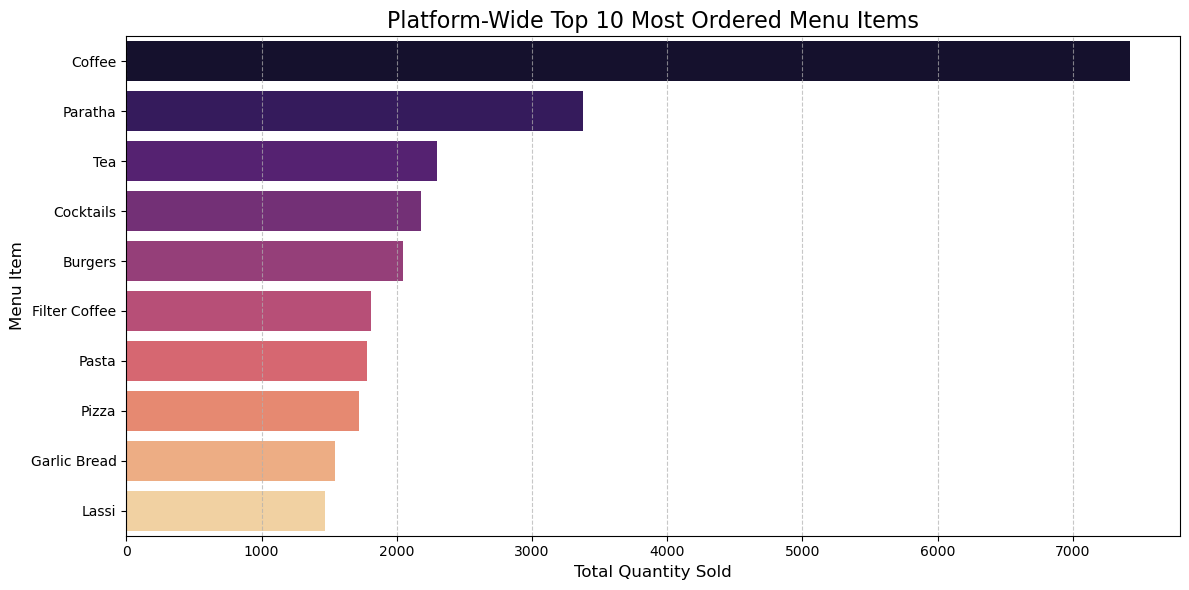

In [17]:
top_10_items_pd = top_ordered_items.limit(10).toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_items_pd, 
    x='total_quantity_sold', 
    y='food_item', 
    palette='magma'
)

plt.title('Platform-Wide Top 10 Most Ordered Menu Items', fontsize=16)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Menu Item', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
# Highest Revenue Restaurants

top_revenue_restaurants = df.groupBy("restaurant_id", "restaurant_name") \
    .agg(sum("order_price").alias("total_revenue")) \
    .orderBy(desc("total_revenue"))

print("Top 10 Highest Revenue Restaurants:")
top_revenue_restaurants.show(10, truncate=False)

Top 10 Highest Revenue Restaurants:
+-------------+---------------------------+------------------+
|restaurant_id|restaurant_name            |total_revenue     |
+-------------+---------------------------+------------------+
|9981         |YORK St.                   |777144.5200000004 |
|11108        |The Boozy Griffin          |614060.11         |
|10832        |Flechazo                   |565164.8          |
|8892         |The Yellow Submarine       |539309.2200000002 |
|11240        |The Druid Garden           |538099.69         |
|11885        |Rural Blues                |502947.64000000013|
|9865         |Prost Brew Pub             |491162.13         |
|8873         |Empire Restaurant          |485135.0899999999 |
|10069        |Ssaffron - Shangri-La Hotel|431448.27999999997|
|11189        |RS Shiv Sagar              |348555.0600000003 |
+-------------+---------------------------+------------------+
only showing top 10 rows


In [19]:
# Order Channel Leaders (Online vs. Dine-In)

channel_leaders = df.groupBy("restaurant_id", "restaurant_name") \
    .agg(
        sum(when(col("request_online") == True, 1).otherwise(0)).alias("total_online_orders"),
        
        sum(when(col("request_table") == True, 1).otherwise(0)).alias("total_dine_in_orders")
    )

print("Order Channel Leaders (Online vs Dine-In):")
channel_leaders.show(10, truncate=False)

Order Channel Leaders (Online vs Dine-In):
+-------------+---------------------------+-------------------+--------------------+
|restaurant_id|restaurant_name            |total_online_orders|total_dine_in_orders|
+-------------+---------------------------+-------------------+--------------------+
|11850        |Cafe Coffee Day            |101                |16                  |
|10069        |Ssaffron - Shangri-La Hotel|55                 |8                   |
|11887        |Birbal Darbar              |60                 |7                   |
|10849        |Behrouz Biryani            |4                  |0                   |
|8917         |Artville Cafe              |2                  |0                   |
|6524         |King                       |5                  |2                   |
|4482         |Puchkas                    |1                  |2                   |
|9991         |Srinivasa Mess             |4                  |2                   |
|11673        |Brahmin

In [20]:
top_online_destinations = channel_leaders.orderBy(desc("total_online_orders"))

print("Top Destinations for Online Delivery:")
top_online_destinations.show(5, truncate=False)


top_dine_in_destinations = channel_leaders.orderBy(desc("total_dine_in_orders"))

print("Top Destinations for Physical Dine-In:")
top_dine_in_destinations.show(5, truncate=False)

Top Destinations for Online Delivery:
+-------------+----------------------+-------------------+--------------------+
|restaurant_id|restaurant_name       |total_online_orders|total_dine_in_orders|
+-------------+----------------------+-------------------+--------------------+
|9981         |YORK St.              |455                |68                  |
|11189        |RS Shiv Sagar         |391                |75                  |
|8873         |Empire Restaurant     |362                |55                  |
|9994         |Corner House Ice Cream|357                |64                  |
|11854        |RS Shiv Sagar Express |352                |57                  |
+-------------+----------------------+-------------------+--------------------+
only showing top 5 rows
Top Destinations for Physical Dine-In:
+-------------+----------------------+-------------------+--------------------+
|restaurant_id|restaurant_name       |total_online_orders|total_dine_in_orders|
+-------------+----

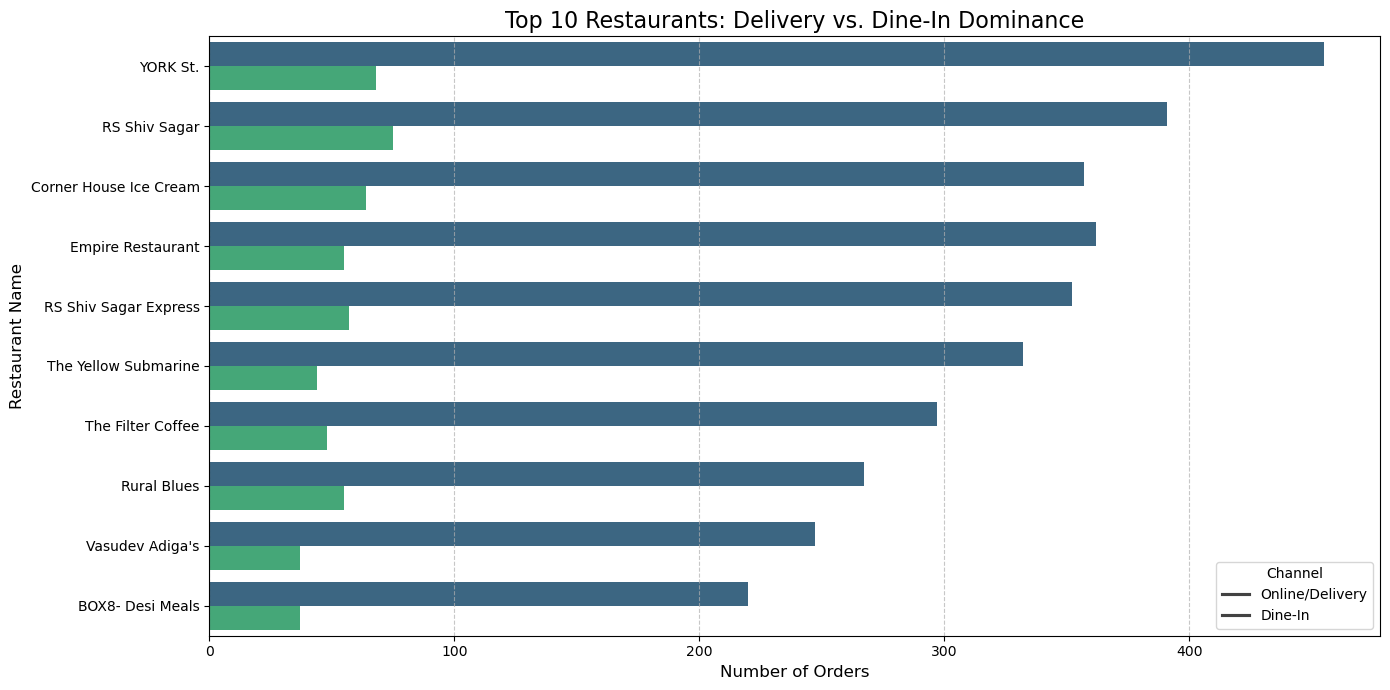

In [21]:
top_10_channels_spark = channel_leaders.withColumn(
    "absolute_total", col("total_online_orders") + col("total_dine_in_orders")
).orderBy(desc("absolute_total")).limit(10)

top_10_channels_pd = top_10_channels_spark.toPandas()

melted_channels = pd.melt(
    top_10_channels_pd, 
    id_vars=['restaurant_name'], 
    value_vars=['total_online_orders', 'total_dine_in_orders'],
    var_name='Order Channel', 
    value_name='Total Orders'
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=melted_channels, 
    x='Total Orders', 
    y='restaurant_name', 
    hue='Order Channel', 
    palette='viridis'
)

plt.title('Top 10 Restaurants: Delivery vs. Dine-In Dominance', fontsize=16)
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Restaurant Name', fontsize=12)
plt.legend(title='Channel', labels=['Online/Delivery', 'Dine-In'])
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Phase 2: Order Time & Peak Hour Analysis

To understand daily demand fluctuations, we analyze the timing of transactions:
1. **Hourly Order Patterns:** We extract the specific hour from the ISO-8601 `order_time` timestamp.
2. **Peak and Off-Peak Identification:** We pinpoint the busiest (rush) and quietest hours of the day.
3. **Visualization:** We convert the aggregated PySpark DataFrame to a Pandas DataFrame to plot the 24-hour order cycle using Matplotlib and Seaborn.

Hourly Order Patterns (0-23):
+----------+------------+
|order_hour|total_orders|
+----------+------------+
|         0|        4433|
|         1|        2797|
|         2|         771|
|         3|         374|
|         4|         355|
|         5|         413|
|         6|         392|
|         7|         375|
|         8|         351|
|         9|         816|
|        10|        1217|
|        11|         931|
|        12|         755|
|        13|         732|
|        14|         981|
|        15|        2446|
|        16|        3672|
|        17|        3618|
|        18|        2434|
|        19|        1185|
|        20|        1218|
|        21|        1168|
|        22|        2686|
|        23|        4291|
+----------+------------+

Peak Hour (Most Crowded):
+----------+------------+
|order_hour|total_orders|
+----------+------------+
|         0|        4433|
+----------+------------+
only showing top 1 row
Off-Peak Hour (Least Crowded):
+----------+------------+
|orde

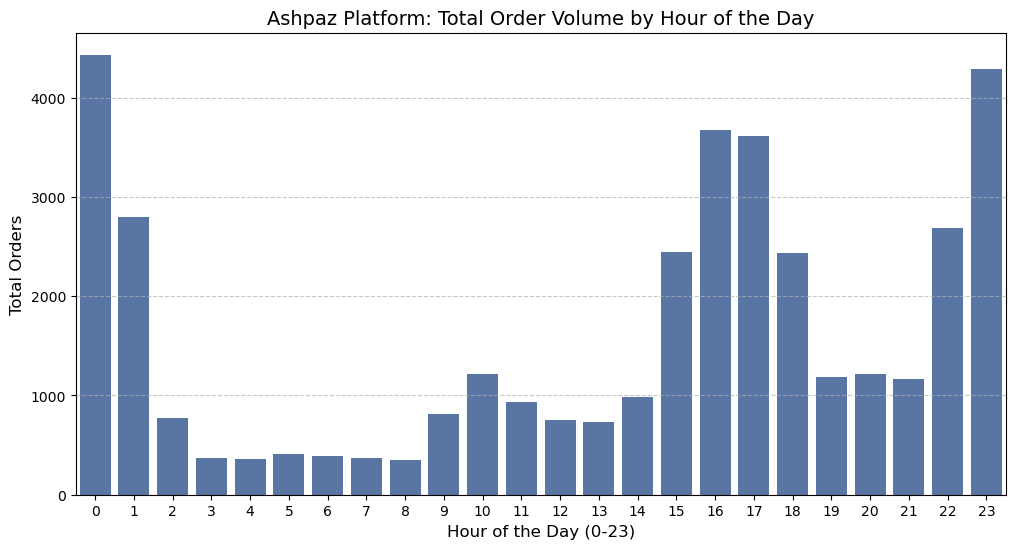

In [22]:
# Hourly Order Patterns
hourly_df = df.withColumn("order_hour", hour(to_timestamp(col("order_time"))))

hourly_patterns = hourly_df.groupBy("order_hour") \
    .agg(count("*").alias("total_orders")) \
    .orderBy("order_hour")

print("Hourly Order Patterns (0-23):")
hourly_patterns.show(24)

print("Peak Hour (Most Crowded):")
hourly_patterns.orderBy(desc("total_orders")).show(1)

print("Off-Peak Hour (Least Crowded):")
hourly_patterns.orderBy("total_orders").show(1)

pandas_hourly_df = hourly_patterns.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(x='order_hour', y='total_orders', data=pandas_hourly_df, color='#4C72B0')

plt.title('Ashpaz Platform: Total Order Volume by Hour of the Day', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Phase 3: Geographic & Location-Based Analysis

The final batch processing step explores regional trends:
1. **Revenue Distribution by City:** We aggregate the total revenue generated in each city.
2. **Regional Favorite Foods:** We use PySpark `Window` functions to rank the exploded items within each city, filtering to find the absolute most popular food item for every region.

In [23]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col, sum, desc, explode

# Revenue Distribution by City
city_revenue = df.groupBy("restaurant_city") \
    .agg(sum("order_price").alias("total_city_revenue")) \
    .orderBy(desc("total_city_revenue"))

print("Revenue Distribution by City:")
city_revenue.show(truncate=False)

# egional Favorite Foods (Menu Preference)
exploded_df = df.withColumn("single_item", explode("items"))

city_food_counts = exploded_df.groupBy("restaurant_city", "single_item.food_item") \
    .agg(sum("single_item.quantity").alias("total_sold"))

windowSpec = Window.partitionBy("restaurant_city").orderBy(desc("total_sold"))

regional_favorites = city_food_counts.withColumn("rank", row_number().over(windowSpec)) \
    .filter(col("rank") == 1) \
    .drop("rank")

print("Regional Favorite Foods (Top Item per City):")
regional_favorites.show(truncate=False)

Revenue Distribution by City:
+---------------------+------------------+
|restaurant_city      |total_city_revenue|
+---------------------+------------------+
|Marathahalli         |2106198.909999999 |
|Whitefield           |1850826.5800000005|
|Malleshwaram         |1799319.7000000004|
|Indiranagar          |1760398.2699999996|
|New BEL Road         |1605811.0700000005|
|Kalyan Nagar         |1585501.11        |
|Lavelle Road         |1547124.4500000004|
|Church Street        |1449158.0300000003|
|Brigade Road         |1412145.52        |
|JP Nagar             |1342925.3400000003|
|Bellandur            |1251210.1199999996|
|HSR                  |1222434.0199999998|
|Koramangala 4th Block|1206861.2899999998|
|Electronic City      |1089863.51        |
|Koramangala 6th Block|1063693.440000001 |
|Bannerghatta Road    |1006703.0099999998|
|BTM                  |992440.7300000003 |
|Basavanagudi         |973112.51         |
|Brookefield          |887426.75         |
|Sarjapur Road        |8

/tmp/ipykernel_10832/2310776861.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


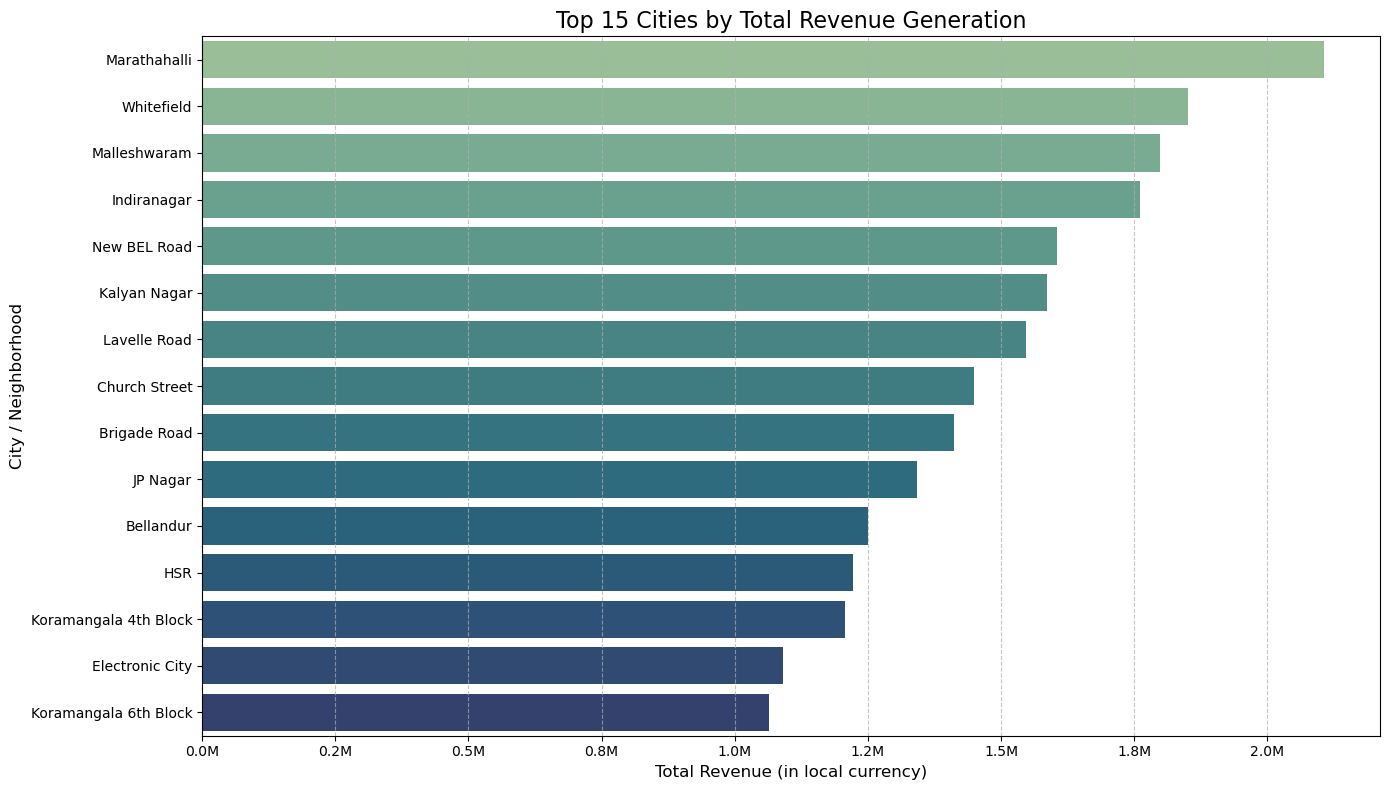

In [24]:
top_15_cities_pd = city_revenue.limit(15).toPandas()

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_15_cities_pd, 
    x='total_city_revenue', 
    y='restaurant_city', 
    palette='crest'
)

plt.title('Top 15 Cities by Total Revenue Generation', fontsize=16)
plt.xlabel('Total Revenue (in local currency)', fontsize=12)
plt.ylabel('City / Neighborhood', fontsize=12)

def millions_formatter(x, pos):
    return f'{x / 1e6:.1f}M'
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()